# IT2011 - Progress Review I — Group Integrated Pipeline
## Group: KU-22 | Dataset: Lung Cancer Dataset (Kaggle)

This notebook combines every member's individual preprocessing step into a
single, ordered pipeline and produces the final cleaned dataset used for
Step 3 (Model Design) of the main assignment.

**Pipeline order (matches the flow of the 6 individual notebooks):**
1. Missing-value audit (IT25101844)
2. Duplicate removal & data-type correction (IT25104015)
3. Outlier handling on numeric columns (IT25101852)
4. Feature engineering — dates → duration, drop `id` (IT25103394)
5. Categorical encoding (IT25101824)
6. Scaling numeric features (IT25101868)
7. Final class-balance check & train/test split, ready for Step 3

Fill in each member's name/IT number in the table below before submitting.

| Step | Technique | Member (Name / IT Number) |
|---|---|---|
| 1 | Missing data handling | ______ |
| 2 | Duplicates & data types / class imbalance | ______ |
| 3 | Outlier removal | ______ |
| 4 | Feature engineering | ______ |
| 5 | Encoding categorical variables | ______ |
| 6 | Normalization / scaling | ______ |


## Step 0 — Load raw data

In [2]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


## Step 1 :- Missing-value audit (IT25101844)

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
# Confirmed clean in the individual notebook -- no imputation needed on the real data.


Missing values per column:
0 total missing cells


## Step 2 :-Duplicate removal & data-type correction (IT25104015)

In [4]:
df = df.drop_duplicates().copy()

df["diagnosis_date"] = pd.to_datetime(df["diagnosis_date"])
df["end_treatment_date"] = pd.to_datetime(df["end_treatment_date"])

for c in ["hypertension", "asthma", "cirrhosis", "other_cancer", "survived"]:
    df[c] = df[c].astype("int8")

print("Shape after de-duplication:", df.shape)
print(df.dtypes)


Shape after de-duplication: (890000, 17)
id                             int64
age                          float64
gender                        object
country                       object
diagnosis_date        datetime64[ns]
cancer_stage                  object
family_history                object
smoking_status                object
bmi                          float64
cholesterol_level              int64
hypertension                    int8
asthma                          int8
cirrhosis                       int8
other_cancer                    int8
treatment_type                object
end_treatment_date    datetime64[ns]
survived                        int8
dtype: object


## Step 3 :- Outlier handling on numeric columns (IT25101852)

In [5]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

num_cols_raw = ["age", "bmi", "cholesterol_level"]
mask_keep = pd.Series(True, index=df.index)
for c in num_cols_raw:
    lower, upper = iqr_bounds(df[c])
    mask_keep &= df[c].between(lower, upper)

print(f"Dropping {(~mask_keep).sum()} outlier rows ({100*(~mask_keep).mean():.2f}% of data)")
df = df[mask_keep].reset_index(drop=True)
print("Shape after outlier removal:", df.shape)


Dropping 3895 outlier rows (0.44% of data)
Shape after outlier removal: (886105, 17)


## Step 4:- Feature engineering (IT25103394)

In [6]:
df["treatment_duration_days"] = (df["end_treatment_date"] - df["diagnosis_date"]).dt.days
df["diagnosis_year"] = df["diagnosis_date"].dt.year

df = df.drop(columns=["id", "diagnosis_date", "end_treatment_date"])
print("Shape after feature engineering:", df.shape)
df.head()


Shape after feature engineering: (886105, 16)


,age,gender,country,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,survived,treatment_duration_days,diagnosis_year
0,64.0,Male,Sweden,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,0,523,2016
1,50.0,Female,Netherlands,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,1,424,2023
2,65.0,Female,Hungary,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,0,370,2023
3,51.0,Female,Belgium,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,0,443,2016
4,37.0,Male,Luxembourg,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,0,406,2023


## Step 5 :- Encoding categorical variables (IT25101824)

In [7]:
df["gender"] = df["gender"].map({"Male": 0, "Female": 1})
df["family_history"] = df["family_history"].map({"No": 0, "Yes": 1})

stage_order = {"Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4}
df["cancer_stage"] = df["cancer_stage"].map(stage_order)

df = pd.get_dummies(df, columns=["smoking_status", "treatment_type"],
                     prefix=["smoking", "treatment"], dtype=int)

df["country"] = df["country"].astype("category").cat.codes

print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (886105, 22)


,age,gender,country,cancer_stage,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,...,treatment_duration_days,diagnosis_year,smoking_Current Smoker,smoking_Former Smoker,smoking_Never Smoked,smoking_Passive Smoker,treatment_Chemotherapy,treatment_Combined,treatment_Radiation,treatment_Surgery
0,64.0,0,26,1,1,29.4,199,0,0,1,...,523,2016,0,0,0,1,1,0,0,0
1,50.0,1,19,3,1,41.2,280,1,1,0,...,424,2023,0,0,0,1,0,0,0,1
2,65.0,1,12,3,1,44.0,268,1,1,0,...,370,2023,0,1,0,0,0,1,0,0
3,51.0,1,1,1,0,43.0,241,1,1,0,...,443,2016,0,0,0,1,1,0,0,0
4,37.0,0,17,1,0,19.7,178,0,0,0,...,406,2023,0,0,0,1,0,1,0,0


## Step 6 :- Scaling numeric features (IT25101868)

In [8]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["age", "bmi", "cholesterol_level", "treatment_duration_days"]
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].describe()


,age,bmi,cholesterol_level,treatment_duration_days
count,8.861050e+05,8.861050e+05,8.861050e+05,8.861050e+05
mean,-3.834552e-17,-9.748117e-16,-4.461615e-17,1.248434e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-2.859368e+00,-1.731983e+00,-1.925518e+00,-1.974448e+00
25%,-7.153874e-01,-8.596568e-01,-8.664452e-01,-6.537258e-01
50%,-7.271342e-04,7.200244e-04,1.926273e-01,-5.426401e-04
75%,7.139331e-01,8.610969e-01,8.603034e-01,6.598183e-01
max,2.857914e+00,1.733423e+00,1.527980e+00,1.951829e+00


## Step 7 :-Final class-balance check & save processed output

survived
0    0.779794
1    0.220206
Name: proportion, dtype: float64


/tmp/ipykernel_3581/484257495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="survived", data=df, palette=["#d9534f", "#5cb85c"])


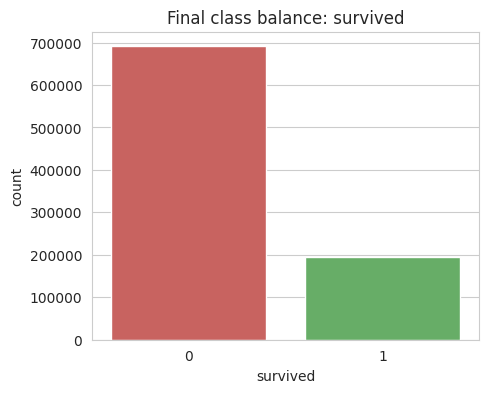

In [9]:
print(df["survived"].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x="survived", data=df, palette=["#d9534f", "#5cb85c"])
plt.title("Final class balance: survived")
plt.show()


In [10]:
import os
os.makedirs("results/outputs", exist_ok=True)
df.to_csv("results/outputs/lung_cancer_processed.csv", index=False)
print("Saved: results/outputs/lung_cancer_processed.csv")
print("Final processed shape:", df.shape)


Saved: results/outputs/lung_cancer_processed.csv
Final processed shape: (886105, 22)


## Summary
Putting it all together: the pipeline checked for missing values (found none),
removed duplicate rows, and corrected the data types across the dataset. It
then removed statistical outliers in age, bmi, and cholesterol level  though
in practice this only affected about 0.4% of rows, and almost all of that came
from age specifically. A new treatment duration days feature was created from
the two date columns, all the categorical variables were encoded (using binary,
ordinal, and one-hot encoding depending on the column), and the numeric features
were standardized.

The result, lung_cancer_processed.csv, is now fully numeric and ready to be fed
into the SVM, Decision Tree, and Neural Network models required in Step 3.

One thing worth flagging for the report: the correlation analysis from the
feature-engineering step showed almost no correlation between any individual
feature and survived, and the target itself is imbalanced at roughly 78% to
22%. Because of that, Step 4 should focus on F1-score, confusion matrices, and
stratified k-fold cross-validation rather than relying on plain accuracy to
judge how well the models perform.